<a href="https://colab.research.google.com/github/franciscosrcoelho-coder/Google-Colab/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [184]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Model

np.random.seed(123)
tf.random.set_seed(123)

In [185]:
!pip install -U scikit-learn

In [186]:
from sklearn.metrics import mean_absolute_percentage_error

In [187]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_absolute_percentage_error, \
  mean_absolute_error, r2_score, mean_squared_error

In [188]:
url = 'https://raw.githubusercontent.com/franciscosrcoelho-coder/Google-Colab/refs/heads/main/Data%20Science%20Applications%20Project%20Data.csv'
df = pd.read_csv(url)

In [189]:
# add the date attribute starting from Jan 2000, with a monthly frequency
df['year_month'] = pd.date_range(start='1/2016', end='4/2026', freq='M',
                                    inclusive='both')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Month        123 non-null    object        
 1   Consumption  123 non-null    int64         
 2   year_month   123 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 3.0+ KB


In [190]:
df=df.drop('Month',axis=1)

In [191]:
df.set_index('year_month', inplace=True)

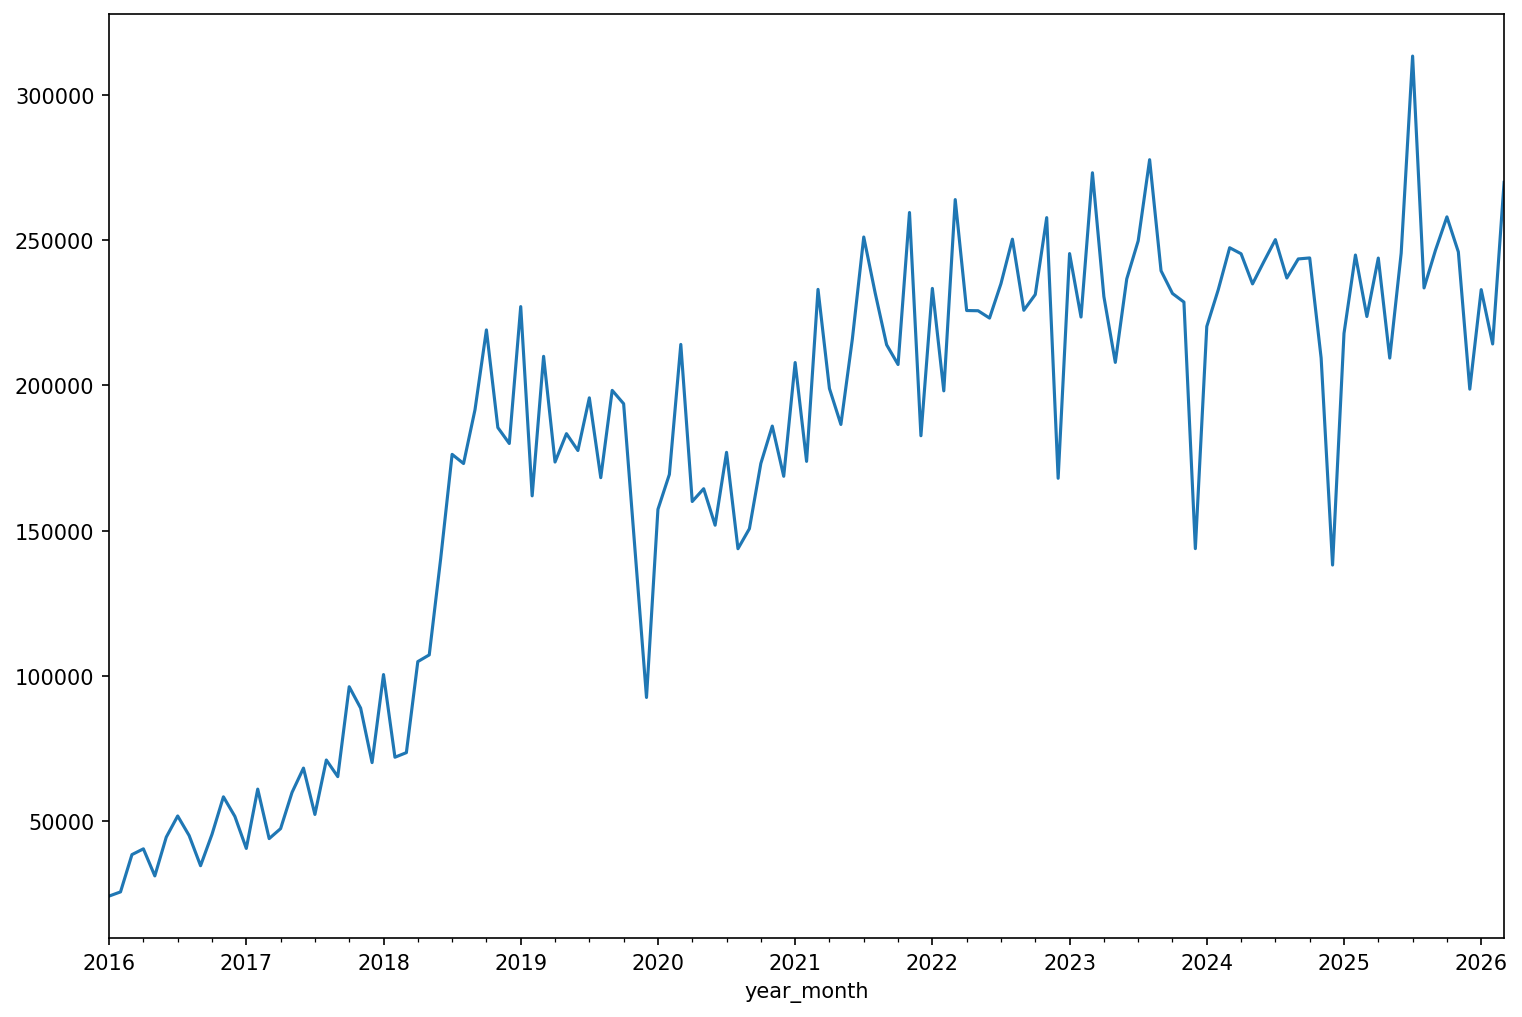

In [192]:
plt.figure(figsize=(12,8),dpi=150)
df['Consumption'].plot();

In [193]:
df.head()

,Consumption
year_month,
2016-01-31,24273
2016-02-29,25715
2016-03-31,38543
2016-04-30,40524
2016-05-31,31222


In [194]:
Ntest = 12
train = df.iloc[:-Ntest]
test = df.iloc[-Ntest:]

In [195]:
# boolean series to index df rows
train_idx = df.index <= train.index[-1]
test_idx = df.index > train.index[-1]

In [196]:
df['DiffConsumption'] = df['Consumption'].diff()

In [197]:
# Make supervised dataset
series = df['DiffConsumption'].dropna().to_numpy()

T = 10
X = []
Y = []
for t in range(len(series) - T):
  x = series[t:t+T]
  X.append(x)
  y = series[t+T]
  Y.append(y)

X = np.array(X).reshape(-1, T)
Y = np.array(Y)
N = len(X)
print("X.shape", X.shape, "Y.shape", Y.shape)

X.shape (112, 10) Y.shape (112,)


In [198]:
Xtrain, Ytrain = X[:-Ntest], Y[:-Ntest]
Xtest, Ytest = X[-Ntest:], Y[-Ntest:]

# **ANN**

In [199]:
# Basic ANN
i = Input(shape=(T,))
x = Dense(32, activation='relu')(i)
x = Dense(1)(x)
model = Model(i, x)

In [200]:
model.compile(
  loss='mse',
  optimizer='adam',
)

In [201]:
r = model.fit(
  Xtrain,
  Ytrain,
  epochs=150,
  validation_data=(Xtest, Ytest)
)

Epoch 1/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 1770871680.0000 - val_loss: 2584619520.0000
Epoch 2/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1694300544.0000 - val_loss: 2533418240.0000
Epoch 3/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 1635772928.0000 - val_loss: 2487249152.0000
Epoch 4/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 1583409664.0000 - val_loss: 2444900096.0000
Epoch 5/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 1536048768.0000 - val_loss: 2406492928.0000
Epoch 6/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 1493176320.0000 - val_loss: 2371693824.0000
Epoch 7/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 1454310016.0000 - val_loss: 2340221952.0000
Epoch 8/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 1418977408.0000 - val_loss: 2311323904.0000
Epoch 9/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 1386894464.0000 - val_loss: 2284939008.0000
Epoch 10/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 1357598720.0000 - val_l

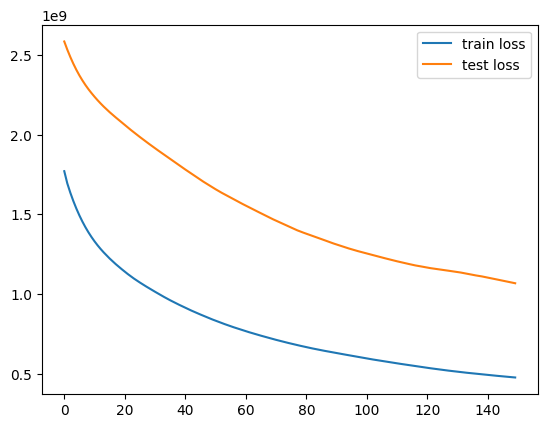

In [202]:
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='test loss')
plt.legend();

In [203]:
train_idx[:T+1] = False # first T+1 values are not predictable

In [204]:
Ptrain = model.predict(Xtrain).flatten()
Ptest = model.predict(Xtest).flatten()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


In [205]:
# Store diff predictions
df.loc[train_idx, 'Diff ANN Train Prediction'] = Ptrain
df.loc[test_idx, 'Diff ANN Test Prediction'] = Ptest

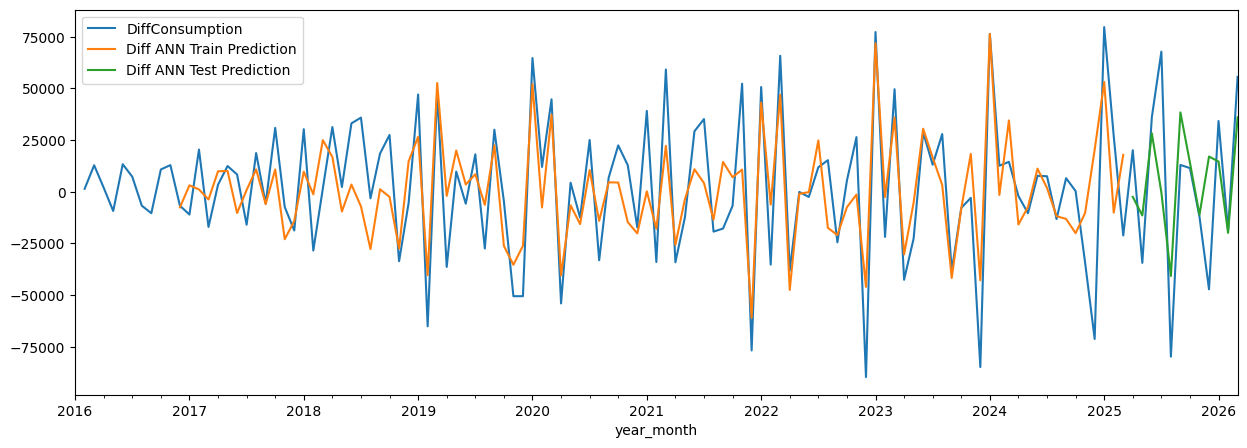

In [206]:
cols = ['DiffConsumption',
        'Diff ANN Train Prediction',
        'Diff ANN Test Prediction']
df[cols].plot(figsize=(15, 5));

In [207]:
# Needed to compute un-differenced predictions
df['ShiftConsumption'] = df['Consumption'].shift(1)
prev = df['ShiftConsumption']

In [208]:
# Last-known train value
last_train = train.iloc[-1]['Consumption']

In [209]:
# 1-step forecast
df.loc[train_idx, '1step_train'] = prev[train_idx] + Ptrain
df.loc[test_idx, '1step_test'] = prev[test_idx] + Ptest

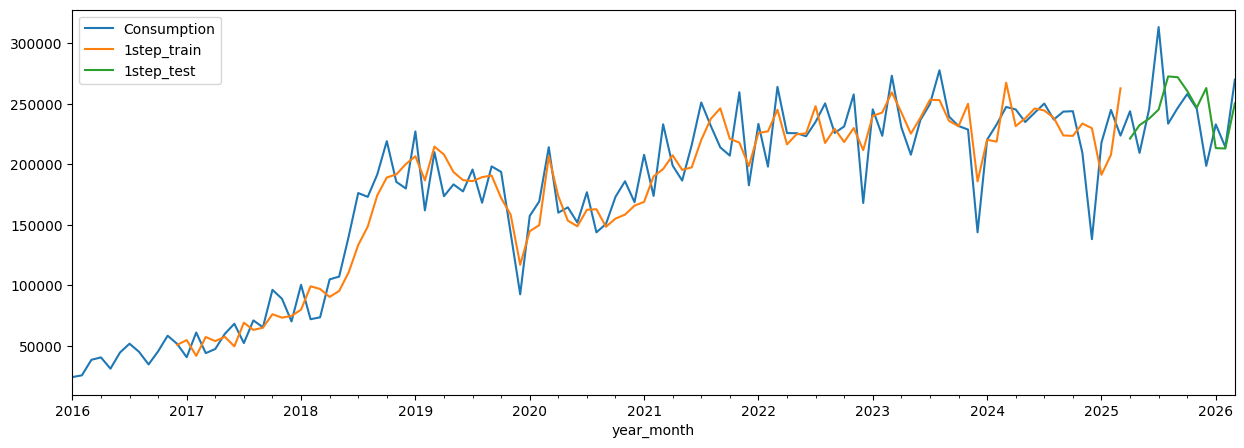

In [210]:
# plot 1-step forecast
df[['Consumption', '1step_train', '1step_test']].plot(figsize=(15, 5));

In [211]:
# multi-step forecast
multistep_predictions = []

# first test input
last_x = Xtest[0]

while len(multistep_predictions) < Ntest:
  p = model.predict(last_x.reshape(1, -1))[0]

  # update the predictions list
  multistep_predictions.append(p)

  # make the new input
  last_x = np.roll(last_x, -1)
  last_x[-1] = p

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


In [212]:
# save multi-step forecast to dataframe
df.loc[test_idx, 'multistep'] = last_train + np.cumsum(multistep_predictions)

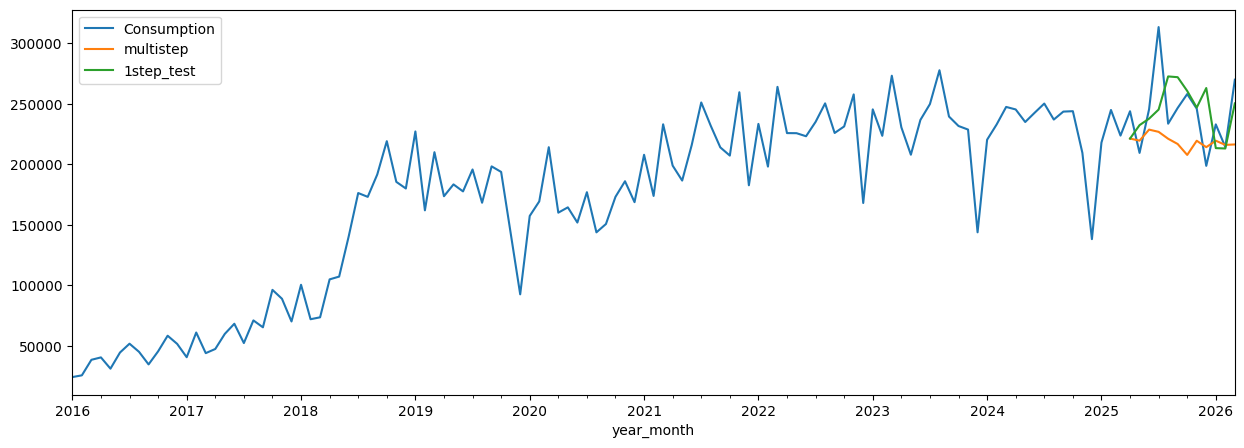

In [213]:
# plot 1-step and multi-step forecast
df[['Consumption', 'multistep', '1step_test']].plot(figsize=(15, 5));

In [214]:
# make multi-output supervised dataset
Tx = T
Ty = Ntest
X = []
Y = []
for t in range(len(series) - Tx - Ty + 1):
  x = series[t:t+Tx]
  X.append(x)
  y = series[t+Tx:t+Tx+Ty]
  Y.append(y)

X = np.array(X).reshape(-1, Tx)
Y = np.array(Y).reshape(-1, Ty)
N = len(X)
print("X.shape", X.shape, "Y.shape", Y.shape)

X.shape (101, 10) Y.shape (101, 12)


In [215]:
Xtrain_m, Ytrain_m = X[:-1], Y[:-1]
Xtest_m, Ytest_m = X[-1:], Y[-1:]

In [216]:
# Basic ANN
i = Input(shape=(Tx,))
x = Dense(32, activation='relu')(i)
x = Dense(Ty)(x)
model = Model(i, x)

In [217]:
model.compile(
  loss='mse',
  optimizer='adam',
)

In [218]:
r = model.fit(
  Xtrain_m,
  Ytrain_m,
  epochs=150,
  validation_data=(Xtest_m, Ytest_m)
)

Epoch 1/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 1625883008.0000 - val_loss: 2178200832.0000
Epoch 2/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1581265536.0000 - val_loss: 2151944448.0000
Epoch 3/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1543115136.0000 - val_loss: 2126866432.0000
Epoch 4/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1507496576.0000 - val_loss: 2102974848.0000
Epoch 5/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1474084992.0000 - val_loss: 2080244096.0000
Epoch 6/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1442710784.0000 - val_loss: 2058742656.0000
Epoch 7/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1413305984.0000 - val_loss: 2038991232.0000
Epoch 8/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1385711744.0000 - val_loss: 2019486080.0000
Epoch 9/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1359716736.0000 - val_loss: 2001103232.0000
Epoch 10/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1335093504.0000 - val_l

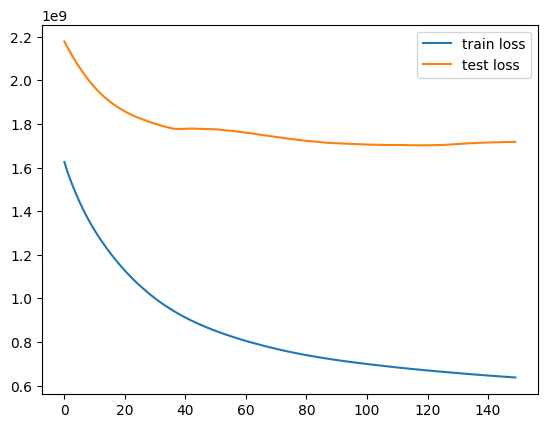

In [219]:
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='test loss')
plt.legend();

In [220]:
Ptrain = model.predict(Xtrain_m)
Ptest = model.predict(Xtest_m)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


In [221]:
Ptrain.shape, Ptest.shape

((100, 12), (1, 12))

In [222]:
Ptrain = Ptrain[:,0]
Ptest = Ptest[0]

In [223]:
# save multi-output forecast to dataframe
df.loc[test_idx, 'multioutput'] = last_train + \
  np.cumsum(Ptest)

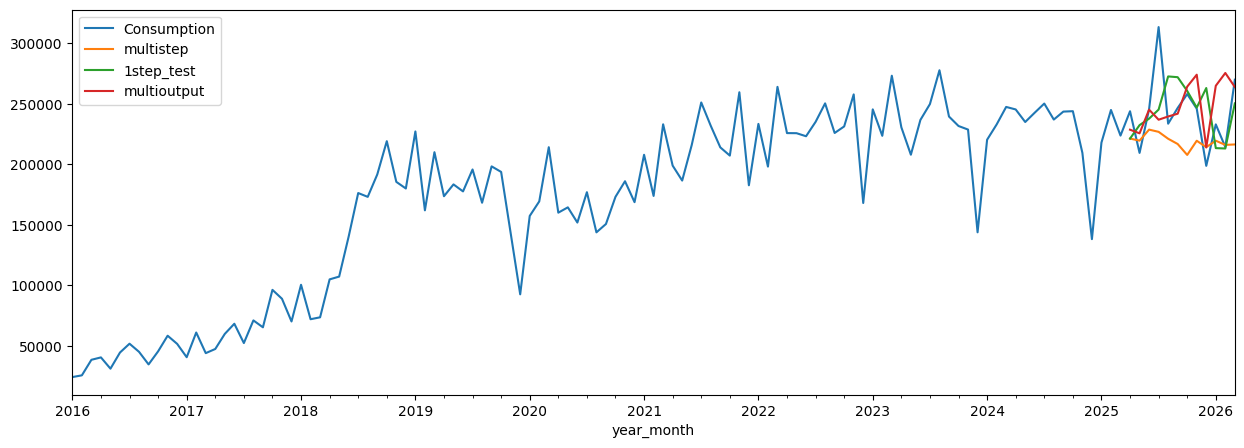

In [224]:
# plot all forecasts
cols = ['Consumption', 'multistep', '1step_test', 'multioutput']
df[cols].plot(figsize=(15, 5));

In [225]:
# MAPE
test_log_pass = df.iloc[-Ntest:]['Consumption']
mape1 = mean_absolute_percentage_error(
    test_log_pass, df.loc[test_idx, 'multistep'])
print("multi-step MAPE:", mape1)
mape2 = mean_absolute_percentage_error(
    test_log_pass, df.loc[test_idx, 'multioutput'])
print("multi-output MAPE:", mape2)

multi-step MAPE: 0.10868529745760863
multi-output MAPE: 0.09076732165361572


# **CNN**

In [226]:
df.head()

,Consumption,DiffConsumption,Diff ANN Train Prediction,Diff ANN Test Prediction,ShiftConsumption,1step_train,1step_test,multistep,multioutput
year_month,,,,,,,,,
2016-01-31,24273,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-02-29,25715,1442.0,NaN,NaN,24273.0,NaN,NaN,NaN,NaN
2016-03-31,38543,12828.0,NaN,NaN,25715.0,NaN,NaN,NaN,NaN
2016-04-30,40524,1981.0,NaN,NaN,38543.0,NaN,NaN,NaN,NaN
2016-05-31,31222,-9302.0,NaN,NaN,40524.0,NaN,NaN,NaN,NaN


In [227]:
df.columns

Index(['Consumption', 'DiffConsumption', 'Diff ANN Train Prediction',
       'Diff ANN Test Prediction', 'ShiftConsumption', '1step_train',
       '1step_test', 'multistep', 'multioutput'],
      dtype='object')

In [228]:
df=df.drop(['Diff ANN Train Prediction',
       'Diff ANN Test Prediction', 'ShiftConsumption', '1step_train',
       '1step_test', 'multistep', 'multioutput'],axis=1)

In [229]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input, GlobalMaxPooling1D
from tensorflow.keras.layers import Conv1D, MaxPooling1D
from tensorflow.keras.models import Model

In [230]:
# CNN
i = Input(shape=(T, 1))
x = Conv1D(16, 3, activation='relu')(i)
x = MaxPooling1D(2)(x)
x = Conv1D(32, 3, activation='relu')(x)
x = GlobalMaxPooling1D()(x)
x = Dense(1)(x)
model = Model(i, x)

In [231]:
model.summary()

Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, 10, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_12 (Conv1D)              │ (None, 8, 16)          │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 4, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_13 (Conv1D)              │ (None, 2, 32)          │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_6          │ (None, 32)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,665 (6.50 KB)

 Trainable params: 1,665 (6.50 KB)

 Non-trainable params: 0 (0.00 B)

In [232]:
model.compile(
  loss='mse',
  optimizer='adam',
)

In [233]:
# CNN
i = Input(shape=(T, 1), dtype=tf.float32)
x = Conv1D(16, 3, activation='relu')(i)
x = MaxPooling1D(2)(x)
x = Conv1D(32, 3, activation='relu')(x)
x = GlobalMaxPooling1D()(x)
x = Dense(1)(x)
model = Model(i, x)

model.compile(
  loss='mse',
  optimizer='adam',
)

Xtrain_cnn = Xtrain.reshape(-1, T, 1).astype(np.float32)
Ytrain_cnn = Ytrain.astype(np.float32)
Xtest_cnn = Xtest.reshape(-1, T, 1).astype(np.float32)
Ytest_cnn = Ytest.astype(np.float32)

r = model.fit(
  Xtrain_cnn,
  Ytrain_cnn,
  epochs=100,
  validation_data=(Xtest_cnn, Ytest_cnn)
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 1280484992.0000 - val_loss: 2029804928.0000
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1230840832.0000 - val_loss: 2042344832.0000
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1209920256.0000 - val_loss: 2038602880.0000
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1185705344.0000 - val_loss: 2017537024.0000
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1159037568.0000 - val_loss: 1992984064.0000
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1135966208.0000 - val_loss: 1973005184.0000
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1115892224.0000 - val_loss: 1958832768.0000
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1097380864.0000 - val_loss: 1952534144.0000
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1080234368.0000 - val_loss: 1948874112.0000
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1063139712.0000 - val_l

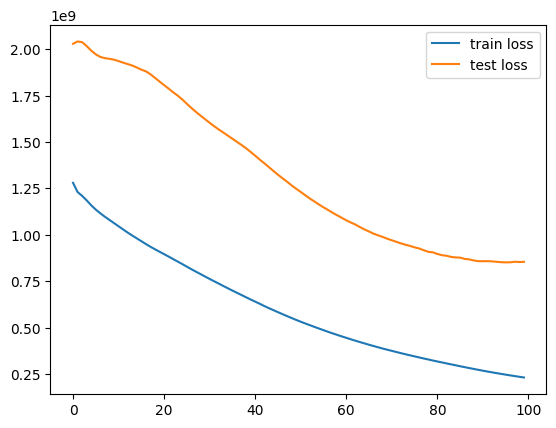

In [234]:
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='test loss')
plt.legend();

In [235]:
train_idx[:T+1] = False # first T+1 values are not predictable

In [236]:
Ptrain = model.predict(Xtrain_cnn).flatten()
Ptest = model.predict(Xtest_cnn).flatten()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


In [237]:
# Store diff predictions
df.loc[train_idx, 'Diff Train Prediction'] = Ptrain
df.loc[test_idx, 'Diff Test Prediction'] = Ptest

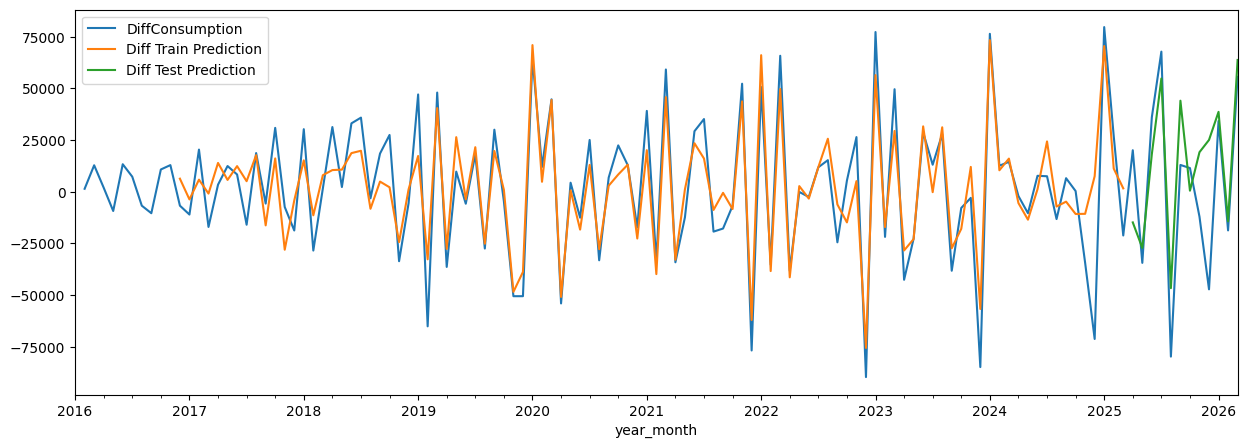

In [238]:
cols = ['DiffConsumption',
        'Diff Train Prediction',
        'Diff Test Prediction']
df[cols].plot(figsize=(15, 5));

In [239]:
# Needed to compute un-differenced predictions
df['ShiftConsumption'] = df['Consumption'].shift(1)
prev = df['ShiftConsumption']

In [240]:
# Last-known train value
last_train = train.iloc[-1]['Consumption']

In [241]:
# 1-step forecast
df.loc[train_idx, '1step_train'] = prev[train_idx] + Ptrain
df.loc[test_idx, '1step_test'] = prev[test_idx] + Ptest

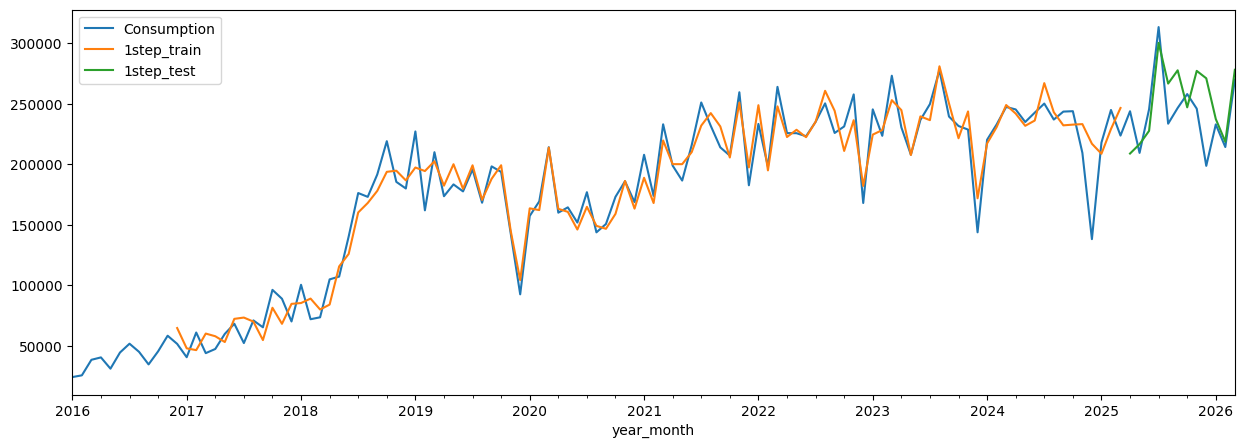

In [242]:
# plot 1-step forecast
df[['Consumption', '1step_train', '1step_test']].plot(figsize=(15, 5));

In [243]:
# multi-step forecast
multistep_predictions = []

# first test input
last_x = Xtest[0]

while len(multistep_predictions) < Ntest:
  p = model.predict(last_x.reshape(1, -1, 1))[0]

  # update the predictions list
  multistep_predictions.append(p)

  # make the new input
  last_x = np.roll(last_x, -1)
  last_x[-1] = p

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


In [244]:
# save multi-step forecast to dataframe
df.loc[test_idx, 'multistep'] = last_train + np.cumsum(multistep_predictions)

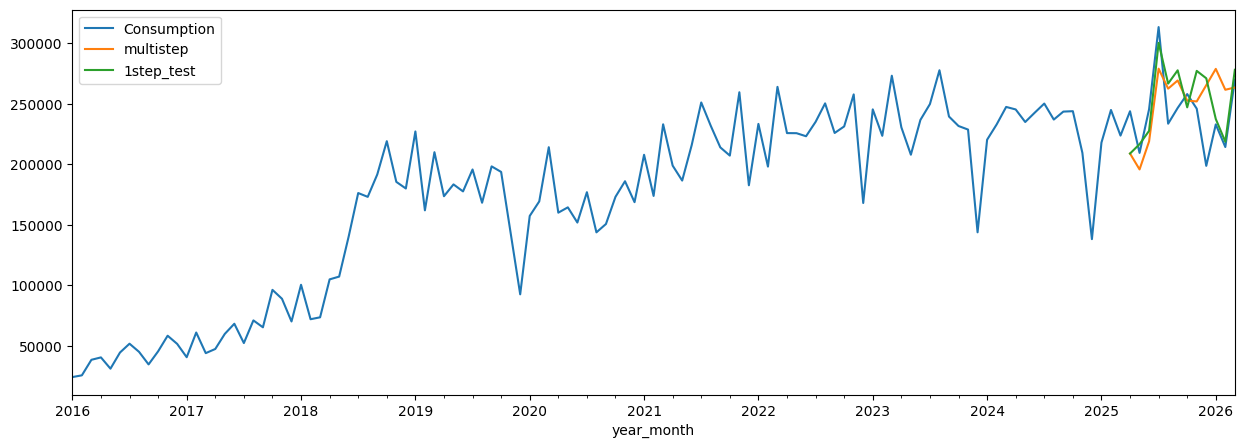

In [245]:
# plot 1-step and multi-step forecast
df[['Consumption', 'multistep', '1step_test']].plot(figsize=(15, 5));

In [246]:
# make multi-output supervised dataset
Tx = T
Ty = Ntest
X = []
Y = []
for t in range(len(series) - Tx - Ty + 1):
  x = series[t:t+Tx]
  X.append(x)
  y = series[t+Tx:t+Tx+Ty]
  Y.append(y)

X = np.array(X).reshape(-1, Tx, 1)
Y = np.array(Y).reshape(-1, Ty)
N = len(X)
print("X.shape", X.shape, "Y.shape", Y.shape)

X.shape (101, 10, 1) Y.shape (101, 12)


In [247]:
Xtrain_m, Ytrain_m = X[:-1], Y[:-1]
Xtest_m, Ytest_m = X[-1:], Y[-1:]

In [248]:
# CNN
i = Input(shape=(Tx, 1))
x = Conv1D(16, 3, activation='relu')(i)
x = MaxPooling1D(2)(x)
x = Conv1D(32, 3, activation='relu')(x)
x = GlobalMaxPooling1D()(x)
x = Dense(Ty)(x)
model = Model(i, x)

In [249]:
model.compile(
  loss='mse',
  optimizer='adam',
)

In [250]:
r = model.fit(
  Xtrain_m,
  Ytrain_m,
  epochs=200,
  validation_data=(Xtest_m, Ytest_m)
)

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 1355613824.0000 - val_loss: 2122284032.0000
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 1334124032.0000 - val_loss: 2089924224.0000
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1320514176.0000 - val_loss: 2065772160.0000
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1310392064.0000 - val_loss: 2045395584.0000
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1302304000.0000 - val_loss: 2025117056.0000
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1295687424.0000 - val_loss: 2008299392.0000
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1289895552.0000 - val_loss: 1997702528.0000
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1284446336.0000 - val_loss: 1992127872.0000
Epoch 9/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1279742720.0000 - val_loss: 1986415232.0000
Epoch 10/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1275232768.0000 - val_l

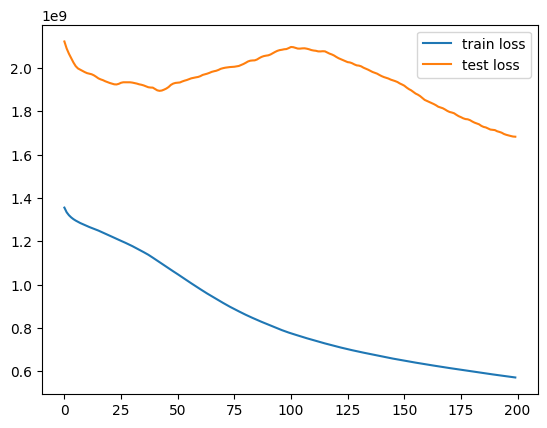

In [251]:
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='test loss')
plt.legend();

In [252]:
Ptrain = model.predict(Xtrain_m)
Ptest = model.predict(Xtest_m)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


In [253]:
Ptrain.shape, Ptest.shape

((100, 12), (1, 12))

In [254]:
Ptrain = Ptrain[:,0]
Ptest = Ptest[0]

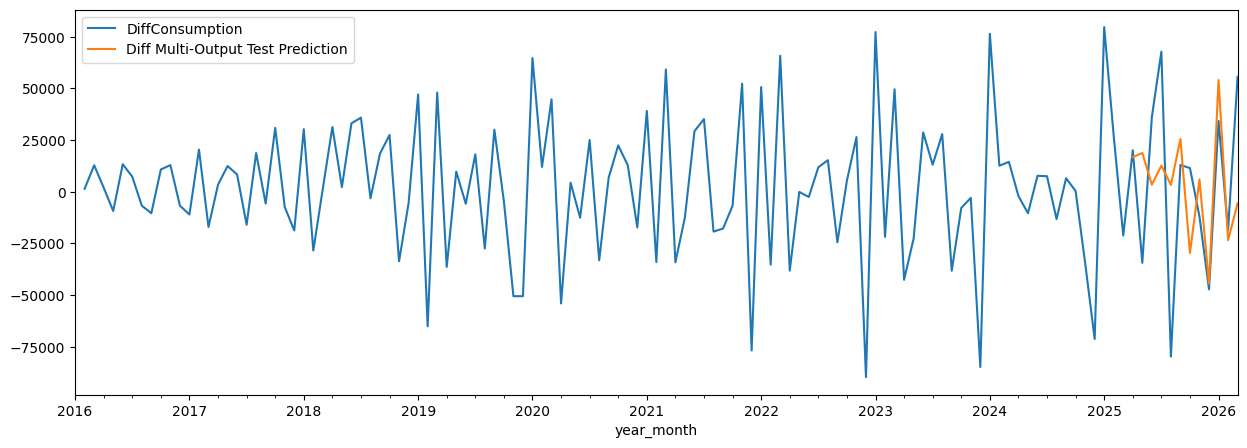

In [255]:
df.loc[test_idx, 'Diff Multi-Output Test Prediction'] = Ptest
cols = ['DiffConsumption', 'Diff Multi-Output Test Prediction']
df[cols].plot(figsize=(15, 5));

In [256]:
# save multi-output forecast to dataframe
df.loc[test_idx, 'multioutput'] = last_train + \
  np.cumsum(Ptest)

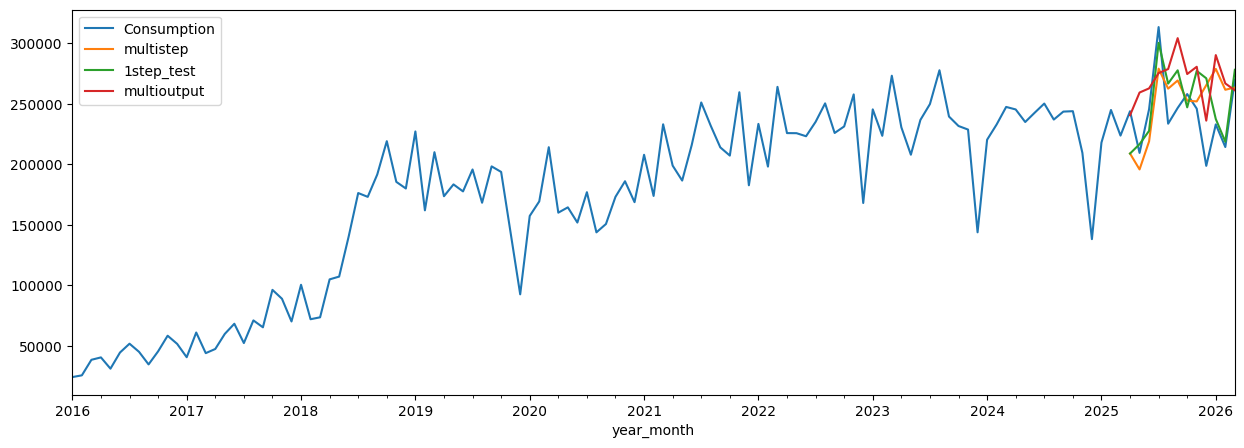

In [257]:
# plot all forecasts
cols = ['Consumption', 'multistep', '1step_test', 'multioutput']
df[cols].plot(figsize=(15, 5));

In [258]:
# MAPE
test_log_pass = df.iloc[-Ntest:]['Consumption']
mape1 = mean_absolute_percentage_error(
    test_log_pass, df.loc[test_idx, 'multistep'])
print("multi-step MAPE:", mape1)
mape2 = mean_absolute_percentage_error(
    test_log_pass, df.loc[test_idx, 'multioutput'])
print("multi-output MAPE:", mape2)

multi-step MAPE: 0.12203923359246747
multi-output MAPE: 0.14883408849442079
